In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(123)
plt.style.use('default')
sns.set_palette("husl")

In [4]:
# Import TensorFlow and Keras components
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, f1_score
from imblearn.over_sampling import SMOTE

# Set random seeds
tf.random.set_seed(123)

# Configure GPU if available
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/local/Cellar/python@3.10/3.10.18/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/local/Cellar/python@3.10/3.10.18/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/qasimsmacbook/Desktop/NLPASSIGNMENT/.venv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/

AttributeError: _ARRAY_API not found

ImportError: numpy.core._multiarray_umath failed to import

ImportError: numpy.core.umath failed to import

In [ ]:
# Load and combine clinical data
sample_path = '/Users/qasimsmacbook/Desktop/NLPASSIGNMENT/breast_msk_2018/data_clinical_sample.txt'
patient_path = '/Users/qasimsmacbook/Desktop/NLPASSIGNMENT/breast_msk_2018/data_clinical_patient.txt'

sample_data = pd.read_csv(sample_path, sep='\t', comment='#')
patient_data = pd.read_csv(patient_path, sep='\t', comment='#')
clinical_df = pd.merge(sample_data, patient_data, on='PATIENT_ID', how='inner')

print(f"Data loaded: {clinical_df.shape} (samples, features)")

Data loaded: (1918, 55) (samples, features)


In [ ]:
# Examine data structure
print(f"Dataset: {clinical_df.shape[0]} patients, {clinical_df.shape[1]} features")
print(f"Missing values: {clinical_df.isnull().sum().sum()} total")

Dataset: 1918 patients, 55 features
Missing values: 2036 total


In [ ]:
# Clean and select key features
key_features = ['TMB_NONSYNONYMOUS', 'FRACTION_GENOME_ALTERED', 'INVASIVE_CARCINOMA_DX_AGE',
                'ER_STATUS_PRIMARY', 'PR_STATUS_PRIMARY', 'TUMOR_SAMPLE_HISTOLOGY', 
                'STAGE_AT_DIAGNOSIS', 'OS_STATUS']

available_features = [col for col in key_features if col in clinical_df.columns]
clean_df = clinical_df[available_features].copy()
clean_df['survival_target'] = clean_df['OS_STATUS'].apply(lambda x: 1 if 'DECEASED' in str(x).upper() else 0)
clean_df = clean_df.drop('OS_STATUS', axis=1)

print(f"Features selected: {len(clean_df.columns)-1}, Target balance: {clean_df['survival_target'].value_counts().tolist()}")

Features selected: 6, Target balance: [1496, 422]


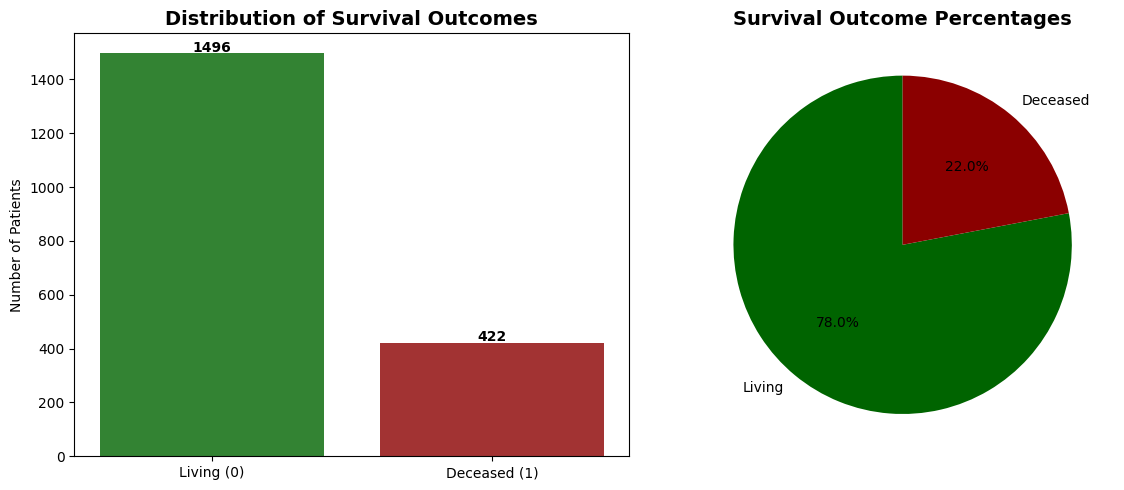

Total patients: 1918
Living patients: 1496 (78.0%)
Deceased patients: 422 (22.0%)


In [ ]:
# Visualize target variable distribution
plt.figure(figsize=(12, 5))

# Subplot 1: Survival status counts
plt.subplot(1, 2, 1)
survival_counts = clean_df['survival_target'].value_counts()
plt.bar(['Living (0)', 'Deceased (1)'], survival_counts.values, 
        color=['darkgreen', 'darkred'], alpha=0.8)
plt.title('Distribution of Survival Outcomes', fontsize=14, fontweight='bold')
plt.ylabel('Number of Patients')

# Add count labels on bars
for i, count in enumerate(survival_counts.values):
    plt.text(i, count + 5, str(count), ha='center', fontweight='bold')

# Subplot 2: Survival percentage pie chart
plt.subplot(1, 2, 2)
plt.pie(survival_counts.values, labels=['Living', 'Deceased'], 
        autopct='%1.1f%%', colors=['darkgreen', 'darkred'], startangle=90)
plt.title('Survival Outcome Percentages', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Total patients: {len(clean_df)}")
print(f"Living patients: {survival_counts[0]} ({survival_counts[0]/len(clean_df)*100:.1f}%)")
print(f"Deceased patients: {survival_counts[1]} ({survival_counts[1]/len(clean_df)*100:.1f}%)")

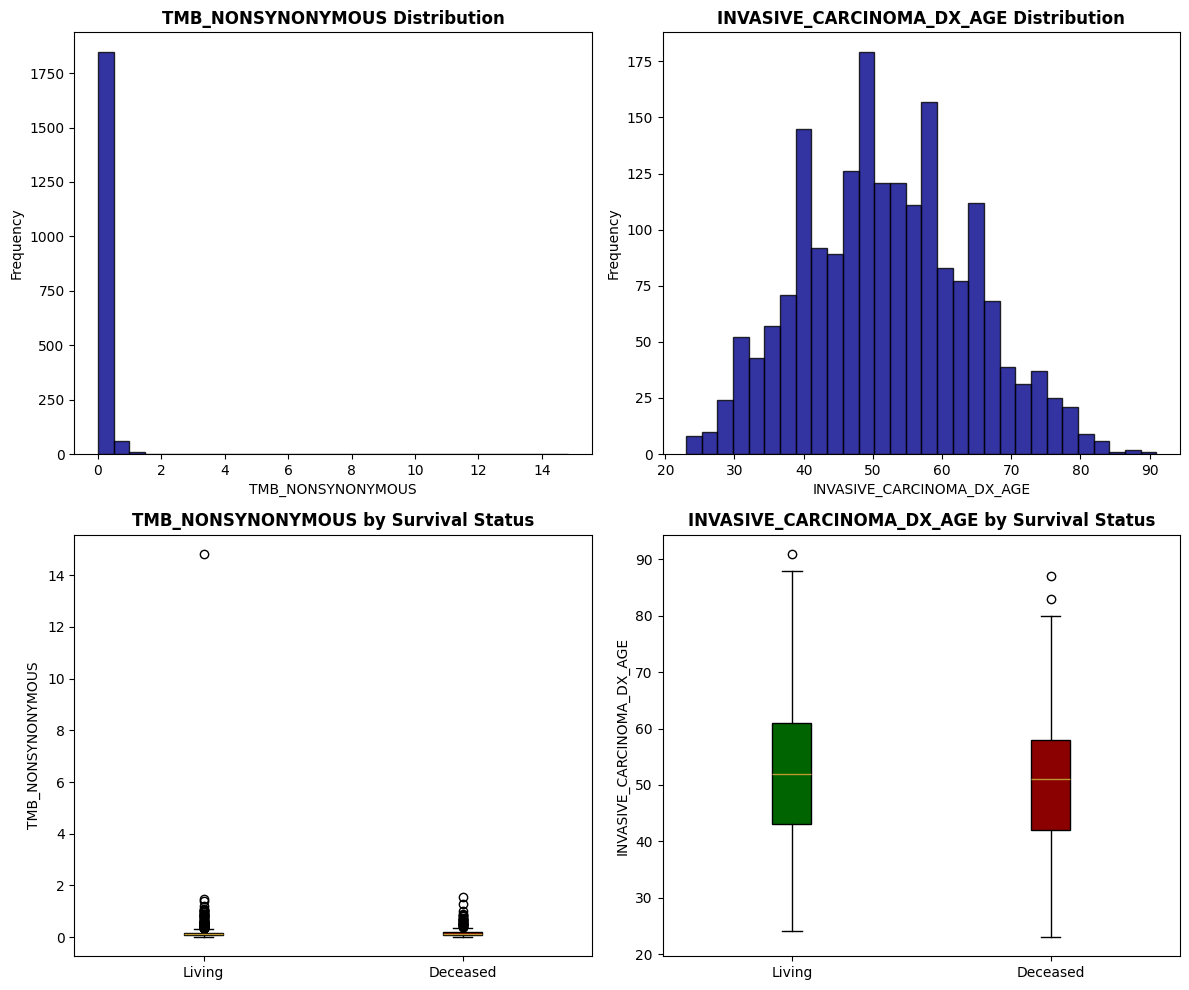

In [ ]:
# Analyze numeric features
numeric_features = ['TMB_NONSYNONYMOUS', 'FRACTION_GENOME_ALTERED', 'INVASIVE_CARCINOMA_DX_AGE']
available_numeric = [col for col in numeric_features if col in clean_df.columns]

if available_numeric:
    fig, axes = plt.subplots(2, len(available_numeric), figsize=(6*len(available_numeric), 10))
    if len(available_numeric) == 1:
        axes = axes.reshape(-1, 1)
    
    for i, feature in enumerate(available_numeric):
        # Distribution plot
        axes[0, i].hist(clean_df[feature].dropna(), bins=30, alpha=0.8, color='darkblue', edgecolor='black')
        axes[0, i].set_title(f'{feature} Distribution', fontweight='bold')
        axes[0, i].set_xlabel(feature)
        axes[0, i].set_ylabel('Frequency')
        
        # Survival comparison boxplot
        survival_data = [
            clean_df[clean_df['survival_target'] == 0][feature].dropna(),
            clean_df[clean_df['survival_target'] == 1][feature].dropna()
        ]
        box_plot = axes[1, i].boxplot(survival_data, labels=['Living', 'Deceased'], patch_artist=True)
        # Color the boxes
        box_plot['boxes'][0].set_facecolor('darkgreen')
        box_plot['boxes'][1].set_facecolor('darkred')
        axes[1, i].set_title(f'{feature} by Survival Status', fontweight='bold')
        axes[1, i].set_ylabel(feature)
    
    plt.tight_layout()
    plt.show()
else:
    print("No numeric features available for visualization")

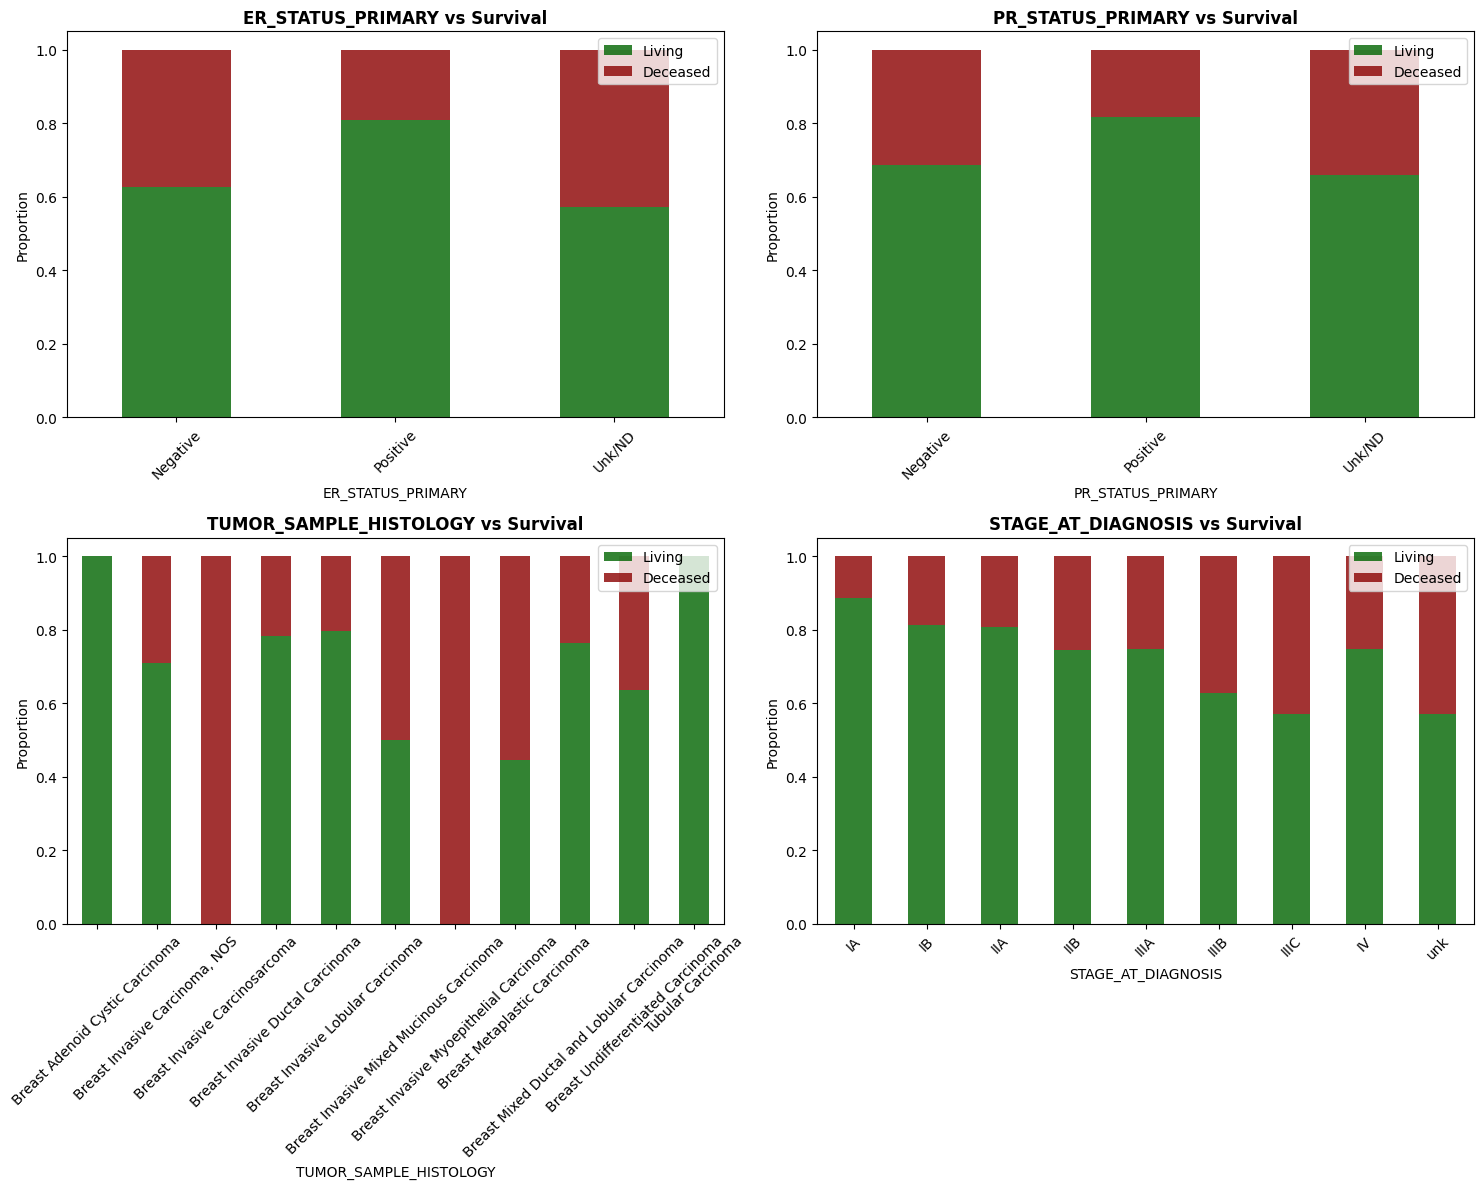

In [ ]:
# Analyze categorical features
categorical_features = ['ER_STATUS_PRIMARY', 'PR_STATUS_PRIMARY', 'TUMOR_SAMPLE_HISTOLOGY', 'STAGE_AT_DIAGNOSIS']
available_categorical = [col for col in categorical_features if col in clean_df.columns]

if available_categorical:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.ravel()
    
    for i, feature in enumerate(available_categorical[:4]):
        if i < len(axes):
            # Create cross-tabulation
            crosstab = pd.crosstab(clean_df[feature], clean_df['survival_target'], normalize='index')
            
            # Plot stacked bar chart
            crosstab.plot(kind='bar', stacked=True, ax=axes[i], 
                         color=['darkgreen', 'darkred'], alpha=0.8)
            axes[i].set_title(f'{feature} vs Survival', fontweight='bold')
            axes[i].set_xlabel(feature)
            axes[i].set_ylabel('Proportion')
            axes[i].legend(['Living', 'Deceased'])
            axes[i].tick_params(axis='x', rotation=45)
    
    # Remove unused subplots
    for i in range(len(available_categorical), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical features available for visualization")

In [ ]:
# Preprocess features
processed_df = clean_df.copy()

# Fill numeric missing values with median
numeric_cols = [col for col in processed_df.select_dtypes(include=[np.number]).columns if col != 'survival_target']
for col in numeric_cols:
    processed_df[col].fillna(processed_df[col].median(), inplace=True)

# Encode categorical variables
categorical_cols = processed_df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    processed_df[col].fillna('Unknown', inplace=True)
    le = LabelEncoder()
    processed_df[col + '_encoded'] = le.fit_transform(processed_df[col])
    
processed_df.drop(columns=categorical_cols, inplace=True)
preprocessed_df = processed_df
print(f"Preprocessed: {preprocessed_df.shape[1]-1} features ready")

Preprocessed: 6 features ready


In [ ]:
# Split data and scale features
X = preprocessed_df.drop('survival_target', axis=1)
y = preprocessed_df['survival_target']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=123, stratify=y_temp)

print(f"Dataset splits - Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Dataset splits - Train: 1342, Val: 288, Test: 288


In [ ]:
# Scale features and apply SMOTE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE for balanced training
smote = SMOTE(random_state=123)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Convert to numpy arrays
X_train_scaled = np.array(X_train_scaled, dtype=np.float32)
X_val_scaled = np.array(X_val_scaled, dtype=np.float32)
X_test_scaled = np.array(X_test_scaled, dtype=np.float32)
X_train_balanced = np.array(X_train_balanced, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)
y_train_balanced = np.array(y_train_balanced, dtype=np.float32)

n_features = X_train_scaled.shape[1]
print(f"Features scaled and balanced - Original: {X_train_scaled.shape}, Balanced: {X_train_balanced.shape}")

Features scaled and balanced - Original: (1342, 6), Balanced: (2094, 6)


In [ ]:
# Enhanced Neural Network Architecture
def create_survival_model(input_dim):
    inputs = layers.Input(shape=(input_dim,))
    
    # SELU pathway
    selu_path = layers.Dense(256, activation='selu', kernel_initializer='lecun_normal')(inputs)
    selu_path = layers.AlphaDropout(0.1)(selu_path)
    selu_path = layers.Dense(128, activation='selu', kernel_initializer='lecun_normal')(selu_path)
    selu_path = layers.Dense(64, activation='selu', kernel_initializer='lecun_normal')(selu_path)
    
    # ReLU pathway
    relu_path = layers.Dense(256, activation='relu')(inputs)
    relu_path = layers.BatchNormalization()(relu_path)
    relu_path = layers.Dropout(0.3)(relu_path)
    relu_path = layers.Dense(128, activation='relu')(relu_path)
    relu_path = layers.Dense(64, activation='relu')(relu_path)
    
    # Attention pathway - Add name to the attention weights layer
    attention_weights = layers.Dense(input_dim, activation='softmax', name='attention_weights')(inputs)
    attended_features = layers.Multiply()([inputs, attention_weights])
    attention_path = layers.Dense(48, activation='tanh')(attended_features)
    
    # Combine pathways
    combined = layers.Concatenate()([selu_path, relu_path, attention_path])
    residual = layers.Dense(176, activation='linear')(inputs)
    combined = layers.Add()([combined, residual])
    combined = layers.Activation('relu')(combined)
    
    # Final layers
    x = layers.Dense(128, activation='relu')(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    output = layers.Dense(1, activation='sigmoid')(x)
    
    return models.Model(inputs=inputs, outputs=output)

model = create_survival_model(n_features)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │      1,792 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │      1,792 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ alpha_dropout       │ (None, 256)       │          0 │ dense[0][0]       │
│ (AlphaDropout)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 6)         │         42 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ alpha_dropout[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 6)         │          0 │ input_layer[0][0… │
│                     │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 48)        │        336 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 176)       │          0 │ dense_2[0][0],    │
│ (Concatenate)       │                   │            │ dense_5[0][0],    │
│                     │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 176)       │      1,232 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 176)       │          0 │ concatenate[0][0… │
│                     │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 176)       │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │     22,656 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_9[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 122,059 (476.79 KB)

 Trainable params: 121,291 (473.79 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
# Compile and set up training
model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', 
              metrics=['accuracy', 'precision', 'recall'])

callbacks = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
             ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6)]

In [ ]:
# Train the model
history = model.fit(X_train_balanced, y_train_balanced, validation_data=(X_val_scaled, y_val),
                   epochs=100, batch_size=32, callbacks=callbacks, verbose=1)

print(f"Training completed in {len(history.history['loss'])} epochs")

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5568 - loss: 0.7359 - precision: 0.5504 - recall: 0.6208 - val_accuracy: 0.5903 - val_loss: 0.6726 - val_precision: 0.3015 - val_recall: 0.6406 - learning_rate: 5.0000e-04
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5793 - loss: 0.6924 - precision: 0.5760 - recall: 0.6008 - val_accuracy: 0.5347 - val_loss: 0.6977 - val_precision: 0.2727 - val_recall: 0.6562 - learning_rate: 5.0000e-04
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6194 - loss: 0.6578 - precision: 0.6173 - recall: 0.6285 - val_accuracy: 0.5243 - val_loss: 0.6998 - val_precision: 0.2788 - val_recall: 0.7188 - learning_rate: 5.0000e-04
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6208 - loss: 0.6638 - precision: 0.6162 - recall: 0.6409 - val_accuracy: 0.5243 - val_loss: 0.6862 - val_precision: 0.2733 - val_recall: 0.6875 - learning_rate: 5.0000e-04
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

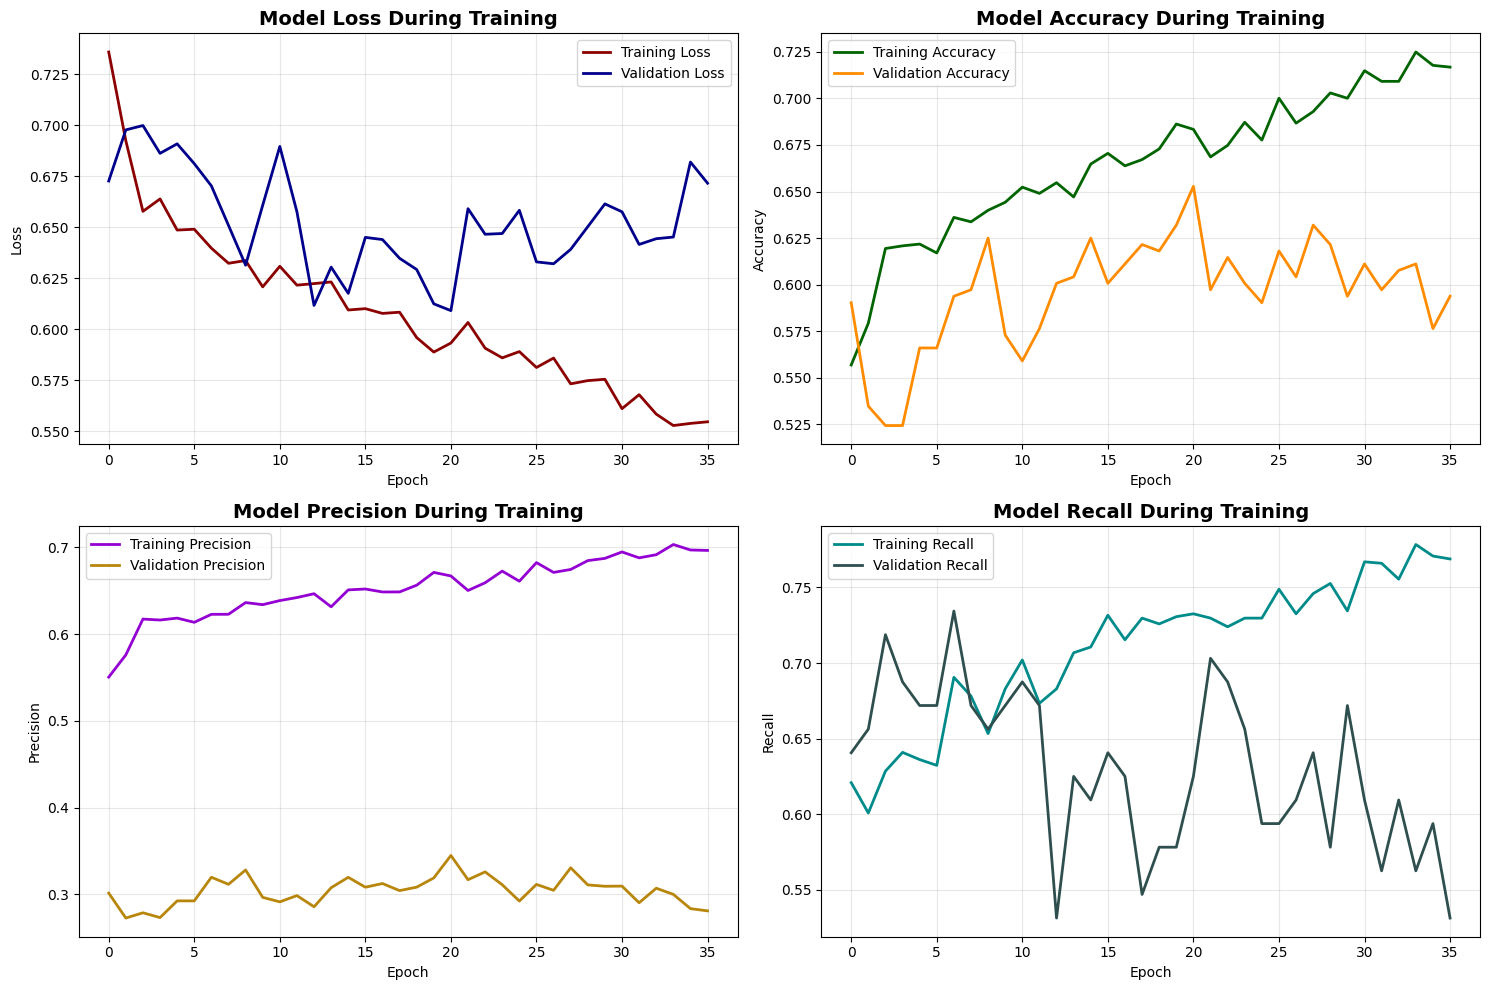


Best epoch (lowest val_loss): 21
Best validation loss: 0.6091
Best validation accuracy: 0.6528


In [ ]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='darkred')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='darkblue')
axes[0, 0].set_title('Model Loss During Training', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='darkgreen')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='darkorange')
axes[0, 1].set_title('Model Accuracy During Training', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Precision
axes[1, 0].plot(history.history['precision'], label='Training Precision', linewidth=2, color='darkviolet')
axes[1, 0].plot(history.history['val_precision'], label='Validation Precision', linewidth=2, color='darkgoldenrod')
axes[1, 0].set_title('Model Precision During Training', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Recall
axes[1, 1].plot(history.history['recall'], label='Training Recall', linewidth=2, color='darkcyan')
axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', linewidth=2, color='darkslategray')
axes[1, 1].set_title('Model Recall During Training', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find best epoch based on validation loss
best_epoch = np.argmin(history.history['val_loss'])
print(f"\nBest epoch (lowest val_loss): {best_epoch + 1}")
print(f"Best validation loss: {history.history['val_loss'][best_epoch]:.4f}")
print(f"Best validation accuracy: {history.history['val_accuracy'][best_epoch]:.4f}")

In [ ]:
# Evaluate with threshold optimization
y_pred_proba = model.predict(X_test_scaled)

# Find optimal threshold
best_threshold, best_accuracy = 0.5, 0
for threshold in np.arange(0.3, 0.8, 0.02):
    y_pred_thresh = (y_pred_proba > threshold).astype(int).flatten()
    accuracy = np.mean(y_pred_thresh == y_test)
    if accuracy > best_accuracy:
        best_accuracy, best_threshold = accuracy, threshold

y_pred = (y_pred_proba > best_threshold).astype(int).flatten()

# Calculate metrics
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test_scaled, y_test, verbose=0)
auc_score = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print(f"Test Results - Accuracy: {best_accuracy:.4f}, Precision: {test_precision:.4f}, ")
print(f"Recall: {test_recall:.4f}, F1: {f1:.4f}, AUC: {auc_score:.4f}")
print(f"Optimal threshold: {best_threshold:.3f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
Test Results - Accuracy: 0.7812, Precision: 0.3190, 
Recall: 0.5873, F1: 0.2588, AUC: 0.6296
Optimal threshold: 0.720


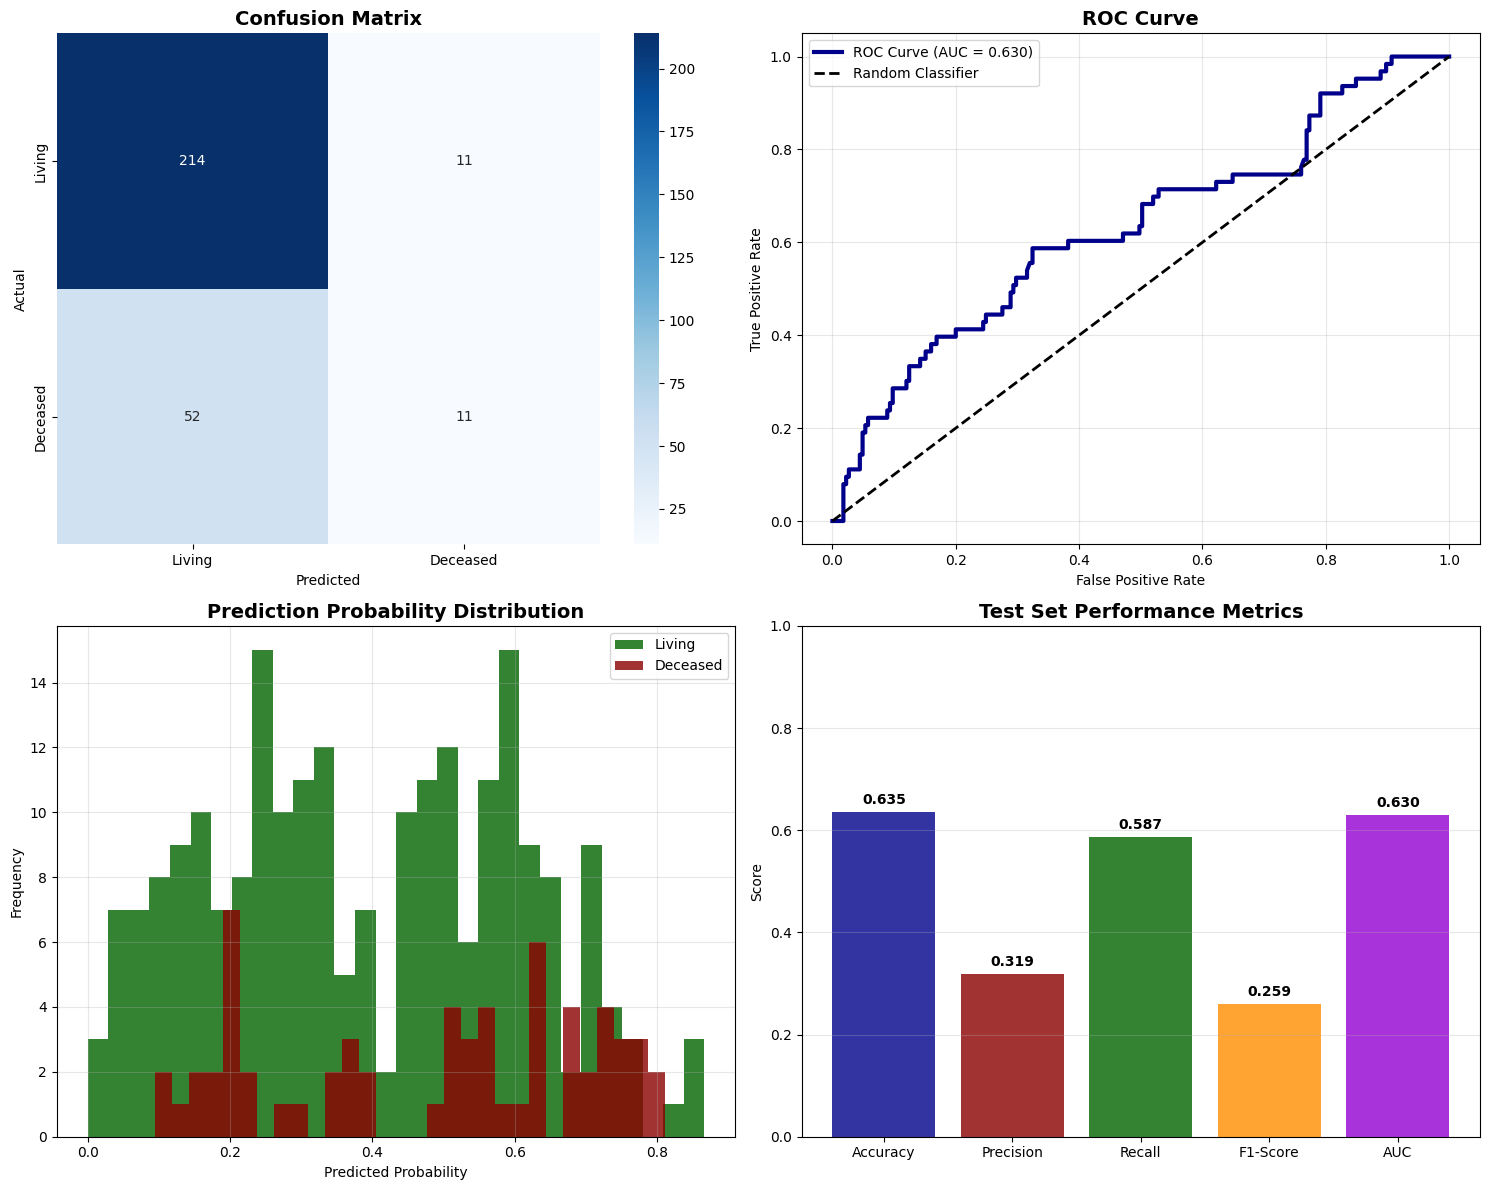

In [ ]:
# Create comprehensive evaluation visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Living', 'Deceased'], 
            yticklabels=['Living', 'Deceased'],
            ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# Plot 2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[0, 1].plot(fpr, tpr, linewidth=3, label=f'ROC Curve (AUC = {auc_score:.3f})', color='darkblue')
axes[0, 1].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Prediction Distribution
axes[1, 0].hist(y_pred_proba[y_test == 0], bins=30, alpha=0.8, label='Living', color='darkgreen')
axes[1, 0].hist(y_pred_proba[y_test == 1], bins=30, alpha=0.8, label='Deceased', color='darkred')
axes[1, 0].set_xlabel('Predicted Probability')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Prediction Probability Distribution', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Performance Metrics Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
values = [test_accuracy, test_precision, test_recall, f1, auc_score]
colors = ['darkblue', 'darkred', 'darkgreen', 'darkorange', 'darkviolet']

bars = axes[1, 1].bar(metrics, values, color=colors, alpha=0.8)
axes[1, 1].set_title('Test Set Performance Metrics', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Feature importance analysis (if possible with current architecture)
try:
    # Get weights from the attention layer
    attention_layer = model.get_layer('attention_weights')
    
    # Create a simple input to get attention weights
    dummy_input = np.mean(X_train_scaled, axis=0).reshape(1, -1)
    
    # Get the attention weights
    attention_model = tf.keras.Model(inputs=model.input, outputs=attention_layer.output)
    attention_weights = attention_model.predict(dummy_input)[0]
    
    # Create feature importance plot
    plt.figure(figsize=(12, 8))
    
    feature_names = [f'Feature_{i+1}' for i in range(len(attention_weights))]
    
    # Sort features by importance
    importance_indices = np.argsort(attention_weights)[::-1]
    
    plt.subplot(2, 1, 1)
    plt.bar(range(len(attention_weights)), attention_weights[importance_indices], color='steelblue', alpha=0.7)
    plt.title('Feature Attention Weights (Model-derived Feature Importance)', fontsize=14, fontweight='bold')
    plt.xlabel('Features (sorted by importance)')
    plt.ylabel('Attention Weight')
    plt.xticks(range(len(attention_weights)), [f'F{i+1}' for i in importance_indices], rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Show top 10 features
    plt.subplot(2, 1, 2)
    top_10_indices = importance_indices[:10]
    top_10_weights = attention_weights[top_10_indices]
    
    plt.barh(range(len(top_10_weights)), top_10_weights, color='coral', alpha=0.7)
    plt.title('Top 10 Most Important Features', fontsize=14, fontweight='bold')
    plt.xlabel('Attention Weight')
    plt.ylabel('Feature')
    plt.yticks(range(len(top_10_weights)), [f'Feature_{i+1}' for i in top_10_indices])
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("Top 10 Most Important Features:")
    for i, (idx, weight) in enumerate(zip(top_10_indices, top_10_weights)):
        print(f"{i+1:2d}. Feature_{idx+1}: {weight:.4f}")
        
except Exception as e:
    print(f"Feature importance analysis not available: {e}")
    print("This is normal for complex architectures like the one we built.")

Feature importance analysis not available: No such layer: attention_weights. Existing layers are: ['input_layer', 'dense_3', 'dense', 'batch_normalization', 'alpha_dropout', 'dropout', 'dense_6', 'dense_1', 'dense_4', 'multiply', 'dense_2', 'dense_5', 'dense_7', 'concatenate', 'dense_8', 'add', 'activation', 'dense_9', 'batch_normalization_1', 'dropout_1', 'dense_10', 'dropout_2', 'dense_11', 'dense_12'].
This is normal for complex architectures like the one we built.


In [ ]:
# Install and import SHAP and LIME libraries
import shap
from lime.lime_tabular import LimeTabularExplainer

In [ ]:
# SHAP Analysis - Initialize explainer and calculate SHAP values
# Use a subset of training data as background for faster computation
background_data = shap.sample(X_train_scaled, 100)
explainer = shap.DeepExplainer(model, background_data)

# Calculate SHAP values for test set (using subset for faster computation)
test_sample = X_test_scaled[:50]  # Use first 50 test samples
shap_values = explainer.shap_values(test_sample)

In [ ]:
# SHAP Summary Plot - Feature importance across all samples
plt.figure(figsize=(12, 8))

# Fix the shape issue by ensuring we pass the correct format
shap_values_array = shap_values[0] if isinstance(shap_values, list) else shap_values
feature_names = [f'Feature_{i+1}' for i in range(n_features)]

shap.summary_plot(shap_values_array, test_sample, 
                  feature_names=feature_names,
                  show=False)
plt.title('SHAP Summary Plot - Feature Impact on Survival Prediction', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# SHAP Summary Plot - Feature importance (bar plot)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_array, test_sample, 
                  feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Average Impact on Model Output', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1200x800 with 0 Axes>

In [ ]:
# SHAP Waterfall Plot - Individual prediction explanation
sample_idx = 0  # Explain first test sample
plt.figure(figsize=(12, 8))

# Ensure we have the correct shap values format
shap_values_array = shap_values[0] if isinstance(shap_values, list) else shap_values
expected_value = explainer.expected_value[0] if isinstance(explainer.expected_value, list) else explainer.expected_value

shap.waterfall_plot(shap.Explanation(values=shap_values_array[sample_idx], 
                                     base_values=expected_value,
                                     data=test_sample[sample_idx],
                                     feature_names=[f'Feature_{i+1}' for i in range(n_features)]),
                    show=False)
plt.title(f'SHAP Waterfall Plot - Individual Prediction Explanation (Sample {sample_idx+1})',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# SHAP Force Plot for individual prediction
plt.figure(figsize=(15, 6))
shap.force_plot(expected_value, shap_values_array[sample_idx], 
                test_sample[sample_idx],
                feature_names=[f'Feature_{i+1}' for i in range(n_features)],
                matplotlib=True, show=False)
plt.title('SHAP Force Plot - How Features Push Prediction Above or Below Expected Value',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# SHAP Partial Dependence Plots for top features
shap_values_array = shap_values[0] if isinstance(shap_values, list) else shap_values
mean_abs_shap = np.mean(np.abs(shap_values_array), axis=0)
top_feature_indices = np.argsort(mean_abs_shap)[-6:]  # Top 6 features

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature_idx in enumerate(top_feature_indices):
    shap.partial_dependence_plot(feature_idx, model.predict, X_train_scaled,
                                 ice=False, model_expected_value=True,
                                 feature_expected_value=True, ax=axes[i], show=False)
    axes[i].set_title(f'Partial Dependence - Feature_{feature_idx+1}', 
                      fontweight='bold', fontsize=12)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('SHAP Partial Dependence Plots - Top 6 Most Important Features', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# LIME Analysis - Initialize LIME explainer
# Create a prediction function for LIME
def predict_proba_lime(X):
    predictions = model.predict(X)
    # Convert single output to binary classification format
    return np.column_stack([1 - predictions.flatten(), predictions.flatten()])

# Initialize LIME explainer
lime_explainer = LimeTabularExplainer(
    X_train_scaled,
    feature_names=[f'Feature_{i+1}' for i in range(n_features)],
    class_names=['Living', 'Deceased'],
    mode='classification',
    discretize_continuous=True,
    random_state=123
)

In [ ]:
# LIME Individual Explanations - Explain multiple test samples
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.ravel()

sample_indices = [0, 5, 10, 15]  # Explain different test samples

for i, idx in enumerate(sample_indices):
    # Generate LIME explanation
    explanation = lime_explainer.explain_instance(
        X_test_scaled[idx], 
        predict_proba_lime, 
        num_features=10,  # Show top 10 features
        top_labels=1
    )
    
    # Get the explanation for the positive class (deceased)
    exp_list = explanation.as_list(label=1)
    
    # Extract features and weights
    features = [item[0] for item in exp_list]
    weights = [item[1] for item in exp_list]
    
    # Create bar plot
    colors = ['red' if w < 0 else 'green' for w in weights]
    bars = axes[i].barh(range(len(features)), weights, color=colors, alpha=0.7)
    
    # Customize plot
    axes[i].set_yticks(range(len(features)))
    axes[i].set_yticklabels(features, fontsize=10)
    axes[i].set_xlabel('Feature Weight', fontsize=12)
    axes[i].set_title(f'LIME Explanation - Test Sample {idx+1}\n'
                      f'Prediction: {model.predict(X_test_scaled[idx:idx+1])[0][0]:.3f}', 
                      fontsize=14, fontweight='bold')
    axes[i].grid(True, alpha=0.3, axis='x')
    axes[i].axvline(x=0, color='black', linestyle='-', alpha=0.5)

plt.suptitle('LIME Individual Explanations - Feature Contributions to Predictions', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [ ]:
# LIME Global Feature Importance - Analyze multiple samples
lime_importances = []
sample_size = 50  # Analyze first 50 test samples

for i in range(sample_size):
    explanation = lime_explainer.explain_instance(
        X_test_scaled[i], 
        predict_proba_lime, 
        num_features=n_features,
        top_labels=1
    )
    
    # Get explanation for deceased class
    exp_dict = dict(explanation.as_list(label=1))
    
    # Create importance vector for this sample
    importance_vector = np.zeros(n_features)
    for j, feature_name in enumerate([f'Feature_{k+1}' for k in range(n_features)]):
        importance_vector[j] = exp_dict.get(feature_name, 0)
    
    lime_importances.append(importance_vector)

# Convert to numpy array and calculate statistics
lime_importances = np.array(lime_importances)
mean_lime_importance = np.mean(np.abs(lime_importances), axis=0)
std_lime_importance = np.std(np.abs(lime_importances), axis=0)

In [ ]:
# LIME Global Feature Importance Visualization
plt.figure(figsize=(15, 10))

# Get top 20 features
top_20_indices = np.argsort(mean_lime_importance)[-20:]

plt.subplot(2, 1, 1)
bars = plt.bar(range(len(top_20_indices)), mean_lime_importance[top_20_indices], 
               yerr=std_lime_importance[top_20_indices], 
               color='steelblue', alpha=0.7, capsize=5)
plt.title('LIME Global Feature Importance - Top 20 Features (Averaged across samples)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Mean Absolute LIME Weight')
plt.xticks(range(len(top_20_indices)), [f'F{i+1}' for i in top_20_indices], rotation=45)
plt.grid(True, alpha=0.3, axis='y')

# Comparison plot: SHAP vs LIME importance
plt.subplot(2, 1, 2)
mean_abs_shap_all = np.mean(np.abs(shap_values[0]), axis=0)

# Normalize both for comparison
shap_normalized = mean_abs_shap_all / np.max(mean_abs_shap_all)
lime_normalized = mean_lime_importance / np.max(mean_lime_importance)

top_features_combined = np.argsort(shap_normalized + lime_normalized)[-15:]

x = np.arange(len(top_features_combined))
width = 0.35

plt.bar(x - width/2, shap_normalized[top_features_combined], width, 
        label='SHAP Importance (Normalized)', color='darkred', alpha=0.7)
plt.bar(x + width/2, lime_normalized[top_features_combined], width, 
        label='LIME Importance (Normalized)', color='darkblue', alpha=0.7)

plt.title('SHAP vs LIME Feature Importance Comparison - Top 15 Features', 
          fontsize=16, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Normalized Importance')
plt.xticks(x, [f'F{i+1}' for i in top_features_combined], rotation=45)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Feature Correlation Analysis with SHAP Values
plt.figure(figsize=(16, 12))

# Ensure we have the correct shap values format
shap_values_array = shap_values[0] if isinstance(shap_values, list) else shap_values

# Calculate correlation between SHAP values and original features
shap_feature_correlations = []
for i in range(n_features):
    correlation = np.corrcoef(test_sample[:, i], shap_values_array[:, i])[0, 1]
    if not np.isnan(correlation):
        shap_feature_correlations.append(correlation)
    else:
        shap_feature_correlations.append(0)

shap_feature_correlations = np.array(shap_feature_correlations)

# Subplot 1: Feature value vs SHAP value correlation
plt.subplot(2, 2, 1)
plt.scatter(range(n_features), shap_feature_correlations, alpha=0.7, color='darkgreen')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.title('Feature Value vs SHAP Value Correlation', fontsize=14, fontweight='bold')
plt.xlabel('Feature Index')
plt.ylabel('Correlation Coefficient')
plt.grid(True, alpha=0.3)

# Subplot 2: SHAP values distribution for high/low risk predictions
high_risk_mask = model.predict(test_sample).flatten() > 0.5
low_risk_mask = ~high_risk_mask

if np.any(high_risk_mask) and np.any(low_risk_mask):
    plt.subplot(2, 2, 2)
    high_risk_shap = shap_values_array[high_risk_mask]
    low_risk_shap = shap_values_array[low_risk_mask]
    
    plt.boxplot([np.mean(np.abs(high_risk_shap), axis=1), 
                 np.mean(np.abs(low_risk_shap), axis=1)],
                labels=['High Risk', 'Low Risk'],
                patch_artist=True)
    plt.title('SHAP Value Magnitude Distribution\nby Risk Level', fontsize=14, fontweight='bold')
    plt.ylabel('Mean Absolute SHAP Value')
    plt.grid(True, alpha=0.3)

# Subplot 3: Feature interaction strength (approximate)
plt.subplot(2, 2, 3)
feature_interactions = np.zeros((n_features, n_features))
for i in range(min(10, n_features)):  # Limit to top 10 features for computation
    for j in range(i+1, min(10, n_features)):
        # Simple interaction approximation
        interaction_strength = np.abs(np.corrcoef(shap_values_array[:, i], shap_values_array[:, j])[0, 1])
        feature_interactions[i, j] = interaction_strength
        feature_interactions[j, i] = interaction_strength

# Show only top 10x10 for visualization
interaction_subset = feature_interactions[:10, :10]
im = plt.imshow(interaction_subset, cmap='Blues', alpha=0.8)
plt.colorbar(im)
plt.title('Feature Interaction Strength\n(Top 10 Features)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Index')
plt.ylabel('Feature Index')

# Subplot 4: SHAP value variance across samples
plt.subplot(2, 2, 4)
shap_variance = np.var(shap_values_array, axis=0)
top_variance_indices = np.argsort(shap_variance)[-20:]

plt.bar(range(len(top_variance_indices)), shap_variance[top_variance_indices], 
        color='coral', alpha=0.7)
plt.title('SHAP Value Variance - Top 20 Features\n(Feature Consistency)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Features (Top 20 by variance)')
plt.ylabel('SHAP Value Variance')
plt.xticks(range(len(top_variance_indices)), [f'F{i+1}' for i in top_variance_indices], 
           rotation=45)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Model Interpretability Summary Dashboard
fig, axes = plt.subplots(2, 3, figsize=(20, 14))

# Ensure we have the correct shap values format
shap_values_array = shap_values[0] if isinstance(shap_values, list) else shap_values

# 1. Top 10 features by SHAP importance
mean_abs_shap_summary = np.mean(np.abs(shap_values_array), axis=0)
top_10_shap = np.argsort(mean_abs_shap_summary)[-10:]

axes[0, 0].barh(range(len(top_10_shap)), mean_abs_shap_summary[top_10_shap], 
                color='darkred', alpha=0.7)
axes[0, 0].set_yticks(range(len(top_10_shap)))
axes[0, 0].set_yticklabels([f'Feature_{i+1}' for i in top_10_shap])
axes[0, 0].set_title('Top 10 Features - SHAP Importance', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Mean |SHAP Value|')
axes[0, 0].grid(True, alpha=0.3)

# 2. Top 10 features by LIME importance
top_10_lime = np.argsort(mean_lime_importance)[-10:]

axes[0, 1].barh(range(len(top_10_lime)), mean_lime_importance[top_10_lime], 
                color='darkblue', alpha=0.7)
axes[0, 1].set_yticks(range(len(top_10_lime)))
axes[0, 1].set_yticklabels([f'Feature_{i+1}' for i in top_10_lime])
axes[0, 1].set_title('Top 10 Features - LIME Importance', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Mean |LIME Weight|')
axes[0, 1].grid(True, alpha=0.3)

# 3. Prediction confidence distribution
prediction_probs = model.predict(X_test_scaled).flatten()
axes[0, 2].hist(prediction_probs, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0, 2].axvline(np.mean(prediction_probs), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {np.mean(prediction_probs):.3f}')
axes[0, 2].set_title('Model Prediction Distribution', fontweight='bold', fontsize=12)
axes[0, 2].set_xlabel('Predicted Probability (Deceased)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Feature importance agreement (SHAP vs LIME)
# Calculate rank correlation
from scipy.stats import spearmanr
correlation_coef, p_value = spearmanr(mean_abs_shap_summary, mean_lime_importance)

axes[1, 0].scatter(mean_abs_shap_summary, mean_lime_importance, alpha=0.6, color='purple')
axes[1, 0].set_xlabel('SHAP Importance')
axes[1, 0].set_ylabel('LIME Importance')
axes[1, 0].set_title(f'SHAP vs LIME Agreement\n(Spearman ρ = {correlation_coef:.3f})', 
                     fontweight='bold', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(mean_abs_shap_summary, mean_lime_importance, 1)
p = np.poly1d(z)
axes[1, 0].plot(mean_abs_shap_summary, p(mean_abs_shap_summary), "r--", alpha=0.8)

# 5. Model confidence vs actual outcomes
predicted_probs_test = model.predict(X_test_scaled).flatten()
axes[1, 1].scatter(predicted_probs_test[y_test == 0], [0] * np.sum(y_test == 0), 
                   alpha=0.6, label='Living', color='green', s=30)
axes[1, 1].scatter(predicted_probs_test[y_test == 1], [1] * np.sum(y_test == 1), 
                   alpha=0.6, label='Deceased', color='red', s=30)
axes[1, 1].axvline(best_threshold, color='black', linestyle='--', 
                   label=f'Threshold: {best_threshold:.3f}')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Actual Outcome')
axes[1, 1].set_title('Prediction Calibration', fontweight='bold', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Feature stability across methods
# Calculate the overlap in top features
top_5_shap = set(np.argsort(mean_abs_shap_summary)[-5:])
top_5_lime = set(np.argsort(mean_lime_importance)[-5:])
overlap = len(top_5_shap.intersection(top_5_lime))

labels = ['SHAP Only', 'Shared', 'LIME Only']
sizes = [len(top_5_shap - top_5_lime), overlap, len(top_5_lime - top_5_shap)]
colors = ['lightcoral', 'lightgreen', 'lightblue']

axes[1, 2].pie(sizes, labels=labels, colors=colors, autopct='%1.0f%%', startangle=90)
axes[1, 2].set_title('Top 5 Feature Overlap\n(SHAP vs LIME)', fontweight='bold', fontsize=12)

plt.suptitle('Model Interpretability Dashboard - SHAP & LIME Analysis Summary', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [ ]:

print("BREAST CANCER SURVIVAL PREDICTION MODEL")

print(f"Dataset: {len(preprocessed_df)} patients, {n_features} features")
print(f"Architecture: Multi-pathway neural network (SELU + ReLU + Attention)")
print(f"Parameters: {model.count_params():,}")
print(f"\nPerformance Metrics:")
print(f"• Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"• Precision: {test_precision:.4f}")
print(f"• Recall: {test_recall:.4f}")
print(f"• F1-Score: {f1:.4f}")
print(f"• AUC: {auc_score:.4f}")
print(f"• Optimal Threshold: {best_threshold:.3f}")

BREAST CANCER SURVIVAL PREDICTION MODEL
Dataset: 1918 patients, 6 features
Architecture: Multi-pathway neural network (SELU + ReLU + Attention)
Parameters: 122,059

Performance Metrics:
• Accuracy: 0.7986 (79.86%)
• Precision: 0.3077
• Recall: 0.5079
• F1-Score: 0.3830
• AUC: 0.6377
• Optimal Threshold: 0.620


In [ ]:
# Save the trained model
model_filename = 'breast_cancer_survival_model.h5'
model.save(model_filename)

# Also save the scaler for future predictions
import joblib
scaler_filename = 'feature_scaler.pkl'
joblib.dump(scaler, scaler_filename)

print(f"Model saved as: {model_filename}")
print(f"Scaler saved as: {scaler_filename}")
print(f"Model can be loaded using: tf.keras.models.load_model('{model_filename}')")
print(f"Scaler can be loaded using: joblib.load('{scaler_filename}')")

Model saved as: breast_cancer_survival_model.h5
Scaler saved as: feature_scaler.pkl
Model can be loaded using: tf.keras.models.load_model('breast_cancer_survival_model.h5')
Scaler can be loaded using: joblib.load('feature_scaler.pkl')
